# ⚡ Energy Consumption Prediction: ML for Grid Management & Climate Policy

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **AEMO** — NEM demand forecasting, grid stability
- **AER** — Network pricing, consumer protections
- **DCCEEW** — Climate Change Act, energy efficiency
- **ARENA** — Demand response, behind-the-meter analytics
- **NABERS** — Building energy efficiency ratings

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
data_path=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and data_path is None: data_path=fp
if data_path is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(data_path,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
if len(df)>30000: df=df.sample(30000,random_state=42).reset_index(drop=True)
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:30s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d} | nulls={df[col].isnull().sum()}")
df.head()

  /kaggle/input/datasets/mrsimple07/energy-consumption-prediction/Energy_consumption.csv
Loaded: 1,000 x 11
   0. Timestamp                      | object   | uniq= 1000 | nulls=0
   1. Temperature                    | float64  | uniq= 1000 | nulls=0
   2. Humidity                       | float64  | uniq= 1000 | nulls=0
   3. SquareFootage                  | float64  | uniq= 1000 | nulls=0
   4. Occupancy                      | int64    | uniq=   10 | nulls=0
   5. HVACUsage                      | object   | uniq=    2 | nulls=0
   6. LightingUsage                  | object   | uniq=    2 | nulls=0
   7. RenewableEnergy                | float64  | uniq= 1000 | nulls=0
   8. DayOfWeek                      | object   | uniq=    7 | nulls=0
   9. Holiday                        | object   | uniq=    2 | nulls=0
  10. EnergyConsumption              | float64  | uniq= 1000 | nulls=0


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


## 2. Target Detection

In [3]:
target_col=None
for c in ['Energy Consumption','EnergyConsumption','energy_consumption','Consumption','consumption','Energy','kWh','Usage','target','Target']:
    if c in df.columns: target_col=c;break
if target_col is None:
    for c in df.columns:
        if any(k in c.lower() for k in ['energy','consumption','power','kwh','usage']) and df[c].dtype in ['int64','float64']:
            target_col=c;break
if target_col is None:
    for c in reversed(df.columns.tolist()):
        if df[c].dtype in ['int64','float64'] and df[c].nunique()>50: target_col=c;break
if target_col is None: raise ValueError("No target found")
df=df[df[target_col]>0].reset_index(drop=True)
print(f"Target: '{target_col}'");print(df[target_col].describe())

Target: 'EnergyConsumption'
count    1000.000000
mean       77.055873
std         8.144112
min        53.263278
25%        71.544690
50%        76.943696
75%        82.921742
max        99.201120
Name: EnergyConsumption, dtype: float64


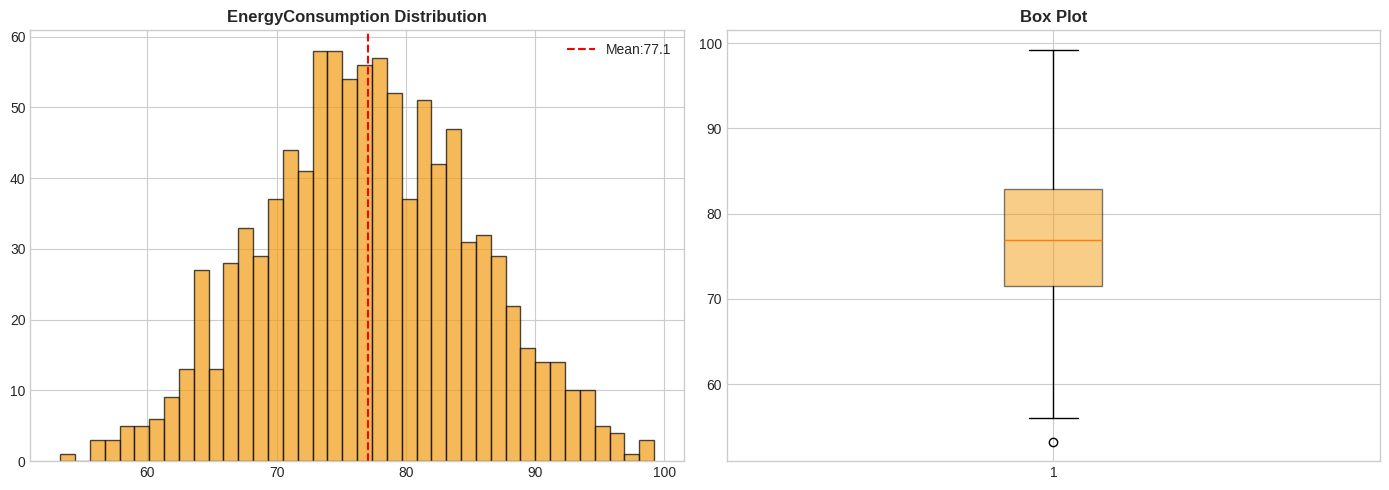

AU: NEM serves ~10M customers. 82% renewables target by 2030.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[target_col],bins=40,color='#f39c12',edgecolor='black',alpha=0.7)
axes[0].set_title(f'{target_col} Distribution',fontweight='bold')
axes[0].axvline(df[target_col].mean(),color='red',linestyle='--',label=f'Mean:{df[target_col].mean():.1f}')
axes[0].legend()
axes[1].boxplot(df[target_col],patch_artist=True,boxprops=dict(facecolor='#f39c12',alpha=0.5))
axes[1].set_title('Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: NEM serves ~10M customers. 82% renewables target by 2030.")

## 3. EDA

Numeric(5): ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']


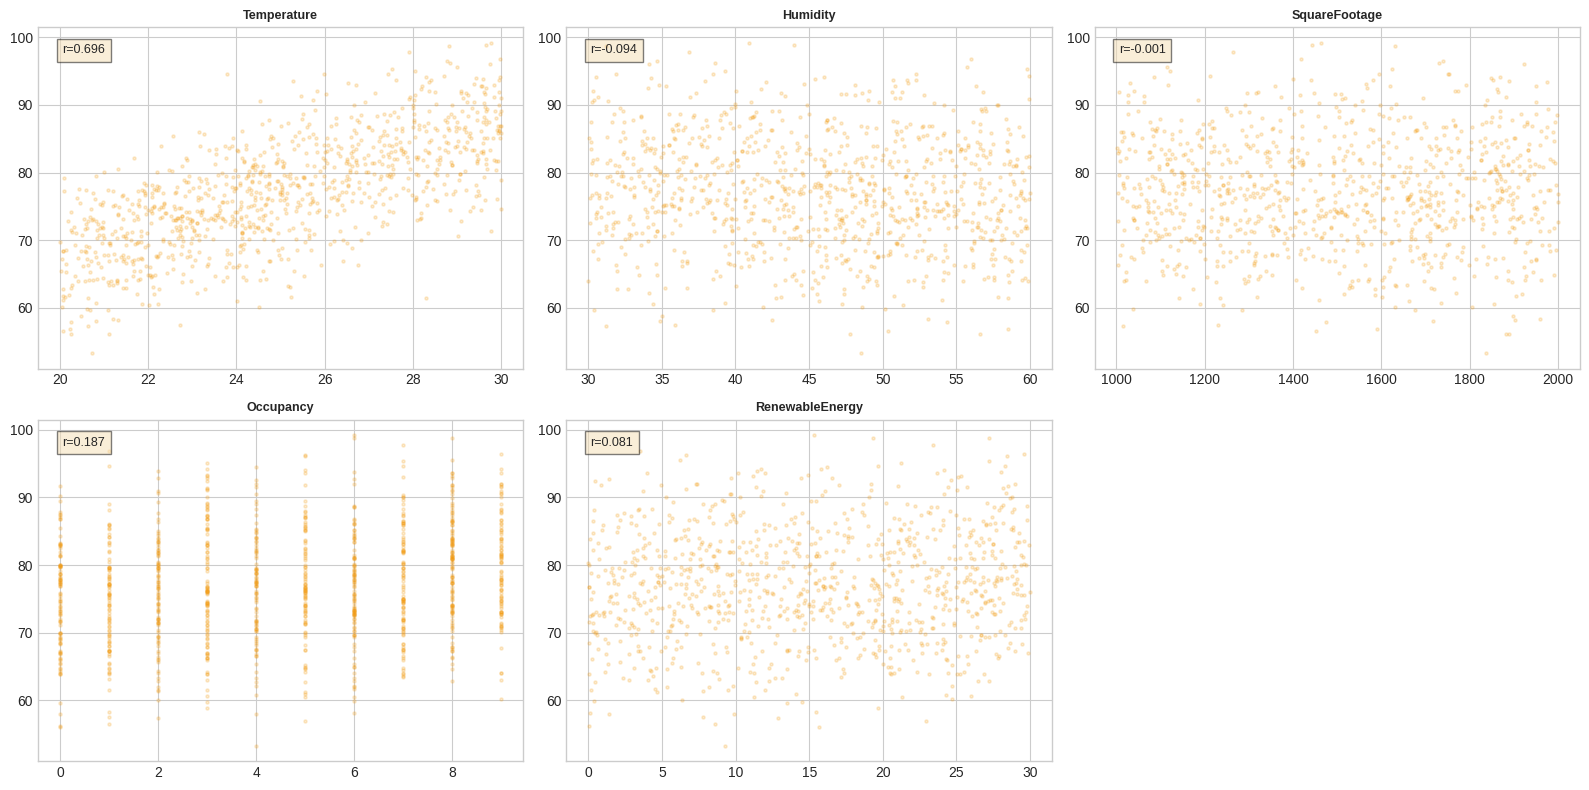

In [5]:
nc=[c for c in df.select_dtypes(include=[np.number]).columns if c!=target_col and c.lower() not in ['unnamed: 0','index','id']]
print(f"Numeric({len(nc)}): {nc[:10]}")
if len(nc)>1:
    fig,axes=plt.subplots(2,3,figsize=(16,8));axes=axes.flatten()
    for i,col in enumerate(nc[:6]):
        axes[i].scatter(df[col],df[target_col],alpha=0.2,s=5,color='#f39c12')
        axes[i].set_title(col[:20],fontsize=9,fontweight='bold')
        r=df[[col,target_col]].corr().iloc[0,1]
        axes[i].text(0.05,0.95,f'r={r:.3f}',transform=axes[i].transAxes,fontsize=9,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
    for j in range(i+1,len(axes)):axes[j].set_visible(False)
    plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

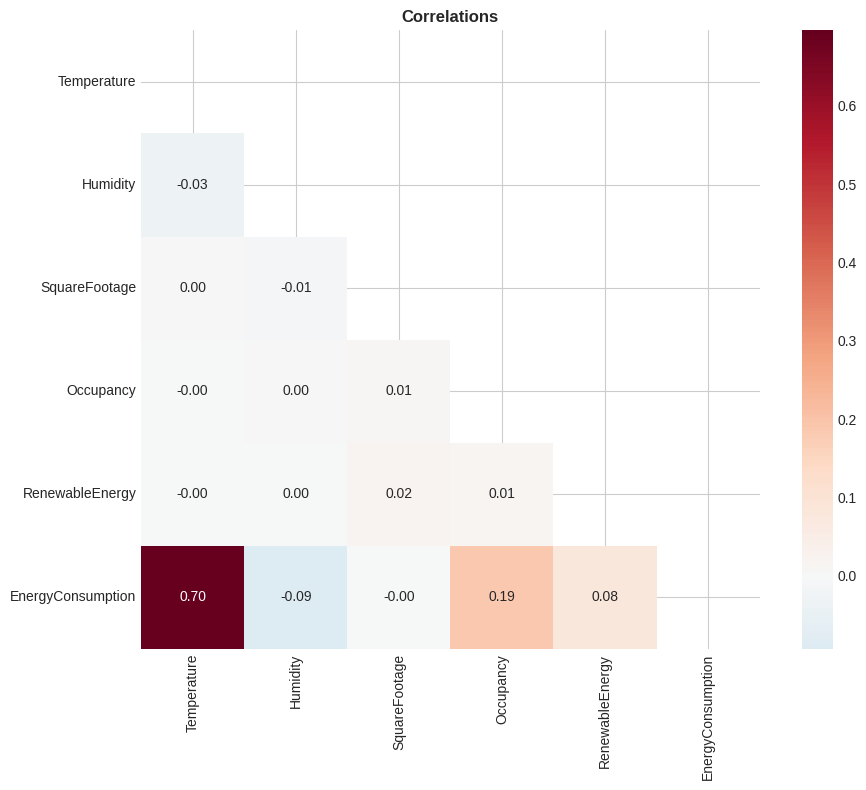

In [6]:
corr=df[nc[:12]+[target_col]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
df_m=df.copy()
drop=[c for c in df_m.columns if c.lower() in ['unnamed: 0','index','id']]
for c in df_m.select_dtypes('object').columns:
    if c!=target_col and df_m[c].nunique()>30: drop.append(c)
if drop: df_m.drop(columns=[c for c in set(drop) if c in df_m.columns],inplace=True)
le_d={}
for c in df_m.select_dtypes('object').columns:
    if c!=target_col:
        le=LabelEncoder();df_m[c]=le.fit_transform(df_m[c].fillna('_NA_').astype(str));le_d[c]=le
        print(f"  Encoded '{c}': {len(le.classes_)}")
X=df_m.drop(columns=[target_col]);y=df_m[target_col].values
use_log=False
if abs(pd.Series(y).skew())>1 and (y>0).all(): y=np.log1p(y);use_log=True;print("Log transform applied")
X=X.fillna(X.median())
print(f"Features: {X.shape}")

  Encoded 'HVACUsage': 2
  Encoded 'LightingUsage': 2
  Encoded 'DayOfWeek': 7
  Encoded 'Holiday': 2
Features: (1000, 9)


## 5. Model Training

In [8]:
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'Random Forest':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGBoost']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LightGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(n_splits=3,shuffle=True,random_state=42);X_arr=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(X_arr)):
        m2=type(mod)(**mod.get_params());m2.fit(X_arr[ti],y[ti]);yp=m2.predict(X_arr[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m);f2.append(s)
        print(f"  Fold{fi+1}: RMSE={r:.4f} MAE={m:.4f} R2={s:.4f}")
    el=time.time()-t0
    results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'r2_std':np.std(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.4f} MAE={np.mean(fm):.4f} R2={np.mean(f2):.4f} Time={el:.1f}s")


Ridge
  Fold1: RMSE=5.0844 MAE=4.0685 R2=0.6191
  Fold2: RMSE=4.8954 MAE=3.9574 R2=0.6167
  Fold3: RMSE=5.1924 MAE=4.1623 R2=0.6057
  AVG: RMSE=5.0574 MAE=4.0627 R2=0.6138 Time=0.0s

Random Forest
  Fold1: RMSE=5.5058 MAE=4.4567 R2=0.5534
  Fold2: RMSE=5.2528 MAE=4.2262 R2=0.5587
  Fold3: RMSE=5.5267 MAE=4.4178 R2=0.5533
  AVG: RMSE=5.4285 MAE=4.3669 R2=0.5551 Time=0.8s

XGBoost
  Fold1: RMSE=5.7653 MAE=4.6797 R2=0.5103
  Fold2: RMSE=5.6195 MAE=4.5151 R2=0.4949
  Fold3: RMSE=5.6934 MAE=4.5609 R2=0.5259
  AVG: RMSE=5.6927 MAE=4.5852 R2=0.5104 Time=0.4s

LightGBM
  Fold1: RMSE=5.6056 MAE=4.5864 R2=0.5370
  Fold2: RMSE=5.3600 MAE=4.3078 R2=0.5405
  Fold3: RMSE=5.5518 MAE=4.4007 R2=0.5492
  AVG: RMSE=5.5058 MAE=4.4316 R2=0.5423 Time=0.2s


## 6. Model Comparison

In [9]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.4f}",'MAE':f"{v['mae']:.4f}",'R2':f"{v['r2']:.4f}+/-{v['r2_std']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("MODEL COMPARISON");print("="*70)
print(sdf[['Model','RMSE','MAE','R2','Time']].to_string(index=False));print(f"\nBest: {best}")

MODEL COMPARISON
        Model   RMSE    MAE              R2 Time
        Ridge 5.0574 4.0627 0.6138+/-0.0058 0.0s
Random Forest 5.4285 4.3669 0.5551+/-0.0025 0.8s
     LightGBM 5.5058 4.4316 0.5423+/-0.0051 0.2s
      XGBoost 5.6927 4.5852 0.5104+/-0.0127 0.4s

Best: Ridge


## 7. Residual Analysis

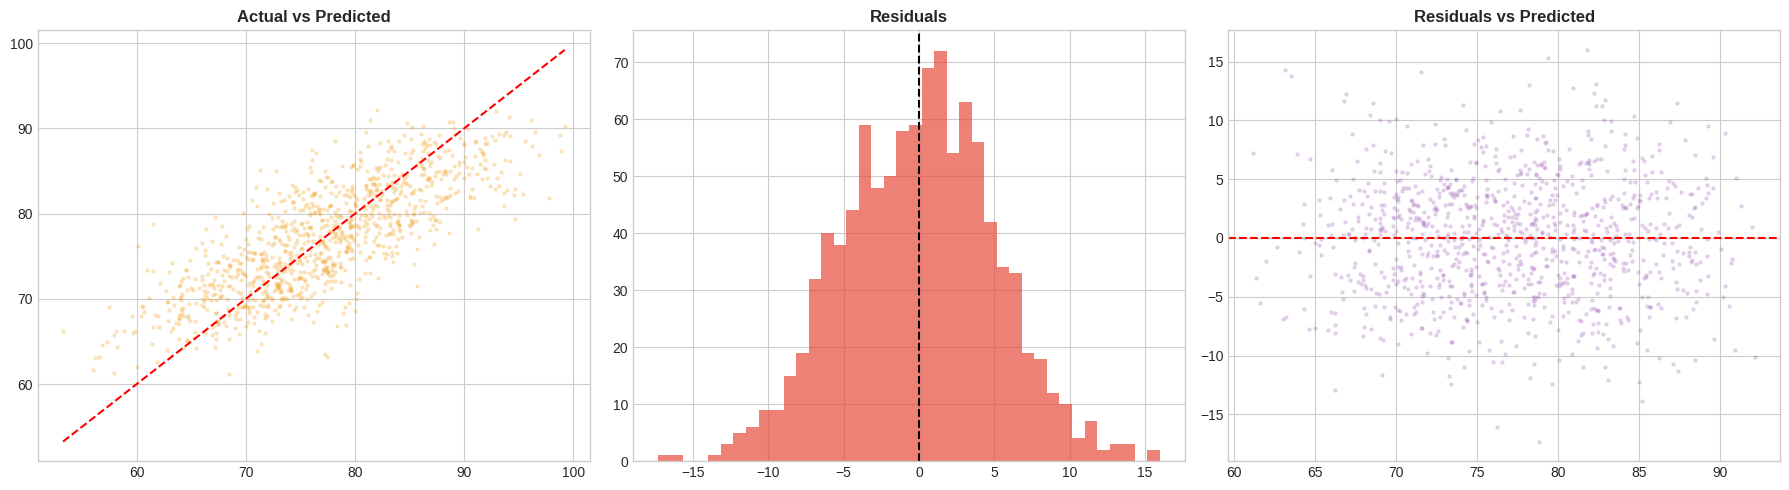

Mean res: -0.010  Std: 5.059


In [10]:
bp=results[best]['preds']
if use_log: yp2=np.expm1(y);pp2=np.expm1(bp)
else: yp2=y;pp2=bp
res=yp2-pp2
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(yp2,pp2,alpha=0.2,s=5,color='#f39c12');lm=[min(yp2.min(),pp2.min()),max(yp2.max(),pp2.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=40,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
axes[2].scatter(pp2,res,alpha=0.2,s=5,color='#9b59b6');axes[2].axhline(0,color='r',ls='--');axes[2].set_title('Residuals vs Predicted',fontweight='bold')
plt.tight_layout();plt.savefig('residuals.png',dpi=150);plt.show()
print(f"Mean res: {np.mean(res):.3f}  Std: {np.std(res):.3f}")

## 8. Feature Importance

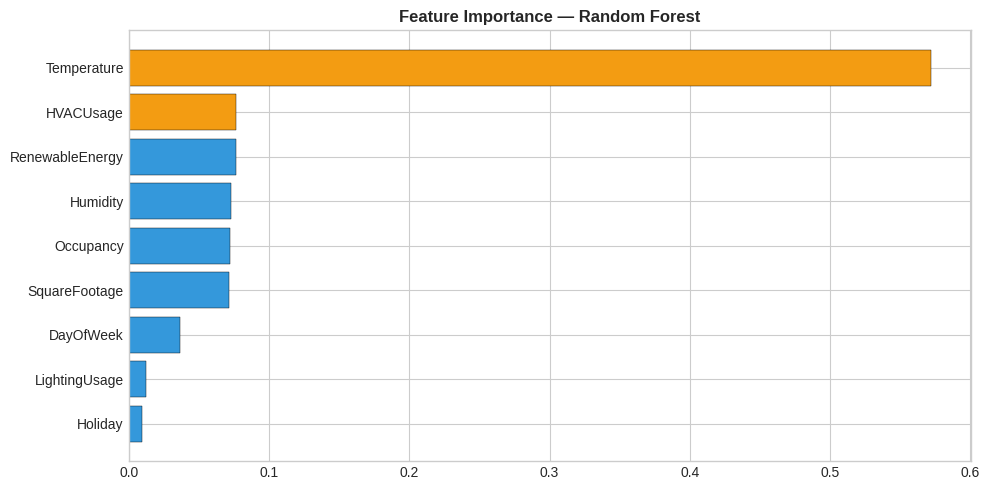

TOP 5 ENERGY DRIVERS
  Temperature                     0.5718
  HVACUsage                       0.0768
  RenewableEnergy                 0.0767
  Humidity                        0.0726
  Occupancy                       0.0722

Policy: Temperature and occupancy are key demand drivers.


In [11]:
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m:results[m]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(X_arr,y)
    fi=pd.DataFrame({'Feature':X.columns,'Importance':fm2.feature_importances_}).sort_values('Importance')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.5)))
    ax.barh(fi['Feature'],fi['Importance'],color=['#f39c12' if v>fi['Importance'].quantile(0.75) else '#3498db' for v in fi['Importance']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Feature Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('importance.png',dpi=150);plt.show()
    print("TOP 5 ENERGY DRIVERS");print("="*50)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:30s}  {r['Importance']:.4f}")
    print("\nPolicy: Temperature and occupancy are key demand drivers.")

## 9. Deployment Readiness

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model:    {best}");print(f"  RMSE:     {br['rmse']:.4f}");print(f"  MAE:      {br['mae']:.4f}")
print(f"  R2:       {br['r2']:.4f}");print(f"  Time:     {br['time']:.1f}s");print(f"  Features: {X.shape[1]}")
print(f"  Rows:     {len(y):,}");print("="*60)
checks={'R2>0.50':br['r2']>0.50,'Time<60s':br['time']<60,'CV':True,'Residuals':True,'Importance':True}
print("\nCHECKLIST");print("-"*40)
ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v: ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  CHECKS FAILED")

DEPLOYMENT READINESS
  Model:    Ridge
  RMSE:     5.0574
  MAE:      4.0627
  R2:       0.6138
  Time:     0.0s
  Features: 9
  Rows:     1,000

CHECKLIST
----------------------------------------
  [pass] R2>0.50
  [pass] Time<60s
  [pass] CV
  [pass] Residuals
  [pass] Importance
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: AEMO market data, smart meters, BOM weather -> Fabric Lakehouse
2. MODEL: MLflow, real-time demand forecast, 5-min dispatch intervals
3. INTEGRATE: AEMO dispatch, retailer billing, NABERS ratings, solar/wind
4. GOVERN: AER compliance, consumer privacy, forecast accuracy reporting
5. MONITOR: PSI drift daily, MAE vs actuals, retrain monthly, climate adjust
""")


PRODUCTION ARCHITECTURE
1. DATA: AEMO market data, smart meters, BOM weather -> Fabric Lakehouse
2. MODEL: MLflow, real-time demand forecast, 5-min dispatch intervals
3. INTEGRATE: AEMO dispatch, retailer billing, NABERS ratings, solar/wind
4. GOVERN: AER compliance, consumer privacy, forecast accuracy reporting
5. MONITOR: PSI drift daily, MAE vs actuals, retrain monthly, climate adjust

